# Machine Learning – Unidad 1  
## Trabajo de desarrollo  
**Tema:** Pipeline reproducible con Titanic – Machine Learning from Disaster  
**Integrante:** Aníbal Díaz Castillo  
**Curso:** Machine Learning  
**Profesor/a:** Franco Andres Mansilla  
**Fecha:** 30 de marzo de 2026

---

## Introducción

En este trabajo se desarrolla un pipeline reproducible de análisis de datos utilizando el dataset *Titanic – Machine Learning from Disaster* de Kaggle. El propósito del estudio es aplicar una metodología estructurada para comprender el problema, explorar la calidad de los datos, ejecutar procesos de limpieza y definir una estrategia adecuada de separación entre entrenamiento, validación y prueba.

El desarrollo se organiza en torno a cuatro ejes principales. Primero, se comparan distintos frameworks de analítica de datos para justificar la metodología seleccionada. Segundo, se realiza un análisis exploratorio del conjunto de datos, identificando variables relevantes, valores faltantes y posibles datos atípicos. Tercero, se revisan diferentes métodos de división del dataset y se justifica la elección del esquema final de trabajo. Por último, se presenta una propuesta de organización del repositorio en GitHub con foco en la reproducibilidad.

El dataset Titanic fue elegido porque constituye un caso clásico de clasificación supervisada y permite observar con claridad cómo variables demográficas y económicas pueden influir en la probabilidad de supervivencia. Además, presenta problemas reales de calidad de datos, como valores faltantes y variables categóricas que requieren transformación, lo que lo convierte en un ejemplo apropiado para un pipeline de ciencia de datos introductorio.

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
DATA_PATH = "../data/train.csv"   # deja el archivo train.csv dentro de la carpeta data

## Instrucciones de uso

1. Descargar desde Kaggle el archivo `train.csv` del dataset Titanic.  
2. Guardarlo dentro de la carpeta `data/` del proyecto.  
3. Ejecutar este notebook desde la primera celda hasta la última.  
4. Completar el nombre del profesor/a y la fecha antes de entregar.

In [32]:
df = pd.read_csv(DATA_PATH)

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Descripción del dataset

El dataset Titanic contiene información sobre pasajeros del viaje, junto con una variable objetivo binaria llamada **Survived**, que indica si el pasajero sobrevivió o no. Entre las variables disponibles se incluyen características demográficas, socioeconómicas y de viaje, como la clase del boleto, sexo, edad, cantidad de familiares a bordo, tarifa pagada y puerto de embarque.

Este conjunto de datos es adecuado para un problema de clasificación supervisada, ya que la variable objetivo es categórica y el objetivo del análisis consiste en identificar patrones que permitan explicar o predecir la supervivencia.

In [33]:
print("Información general:")
df.info()

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))

print("\nResumen estadístico de variables numéricas:")
display(df.describe().T)

print("\nResumen estadístico de variables categóricas:")
display(df.describe(include="object").T)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Tipos de datos:


,tipo
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64



Resumen estadístico de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



Resumen estadístico de variables categóricas:


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [34]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
})

display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [35]:
duplicates = df.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicates)

Cantidad de filas duplicadas: 0


,count,pct
Survived,,
0,549,61.62
1,342,38.38


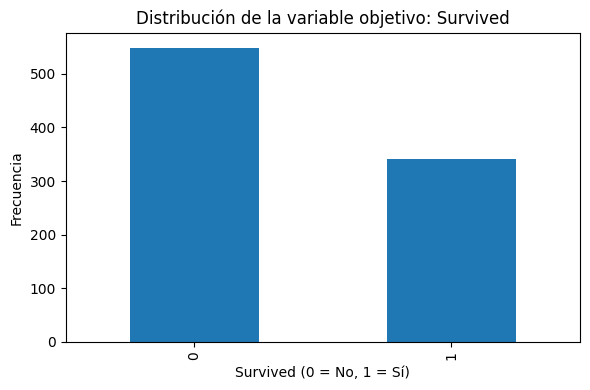

In [36]:
target_counts = df["Survived"].value_counts().sort_index()
target_pct = df["Survived"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct.round(2)
})
display(target_summary)

plt.figure(figsize=(6,4))
df["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo: Survived")
plt.xlabel("Survived (0 = No, 1 = Sí)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

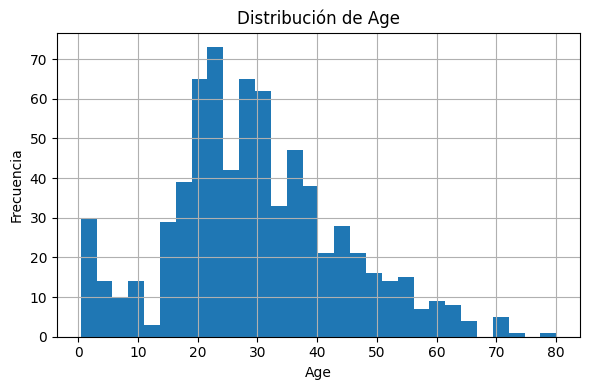

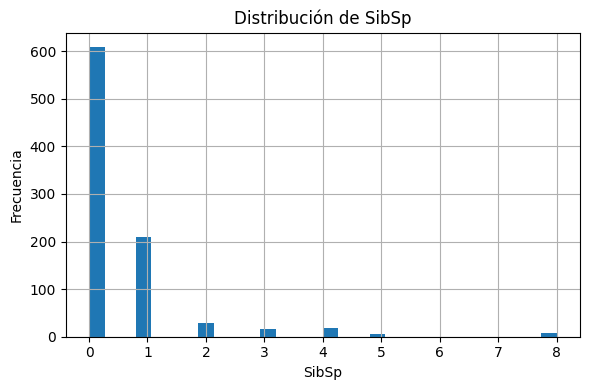

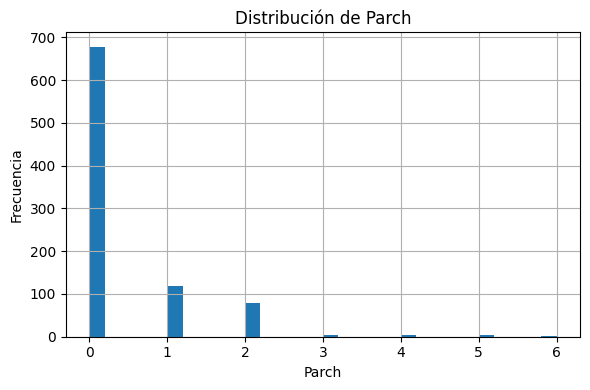

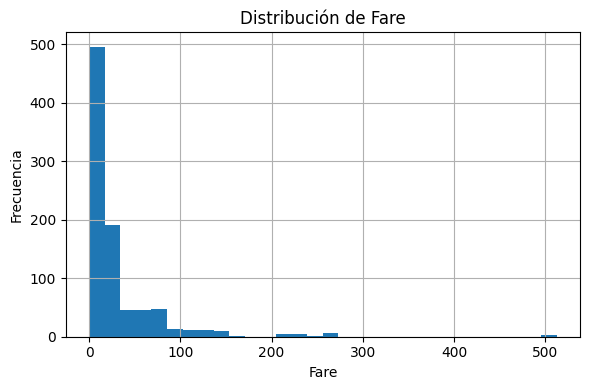

In [37]:
num_cols = ["Age", "SibSp", "Parch", "Fare"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    df[col].dropna().hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

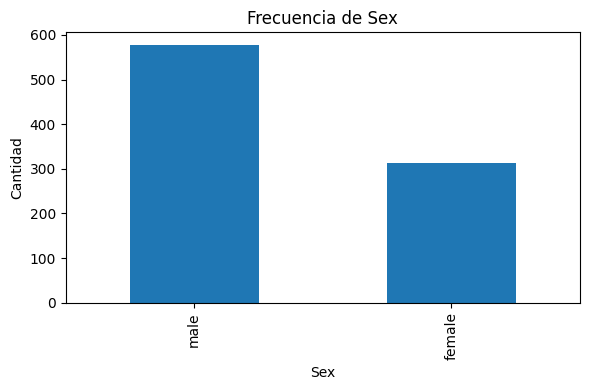

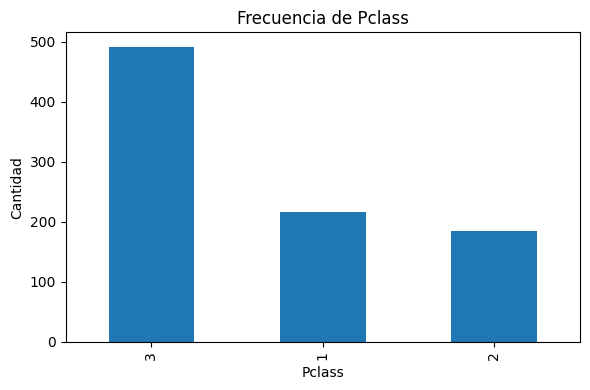

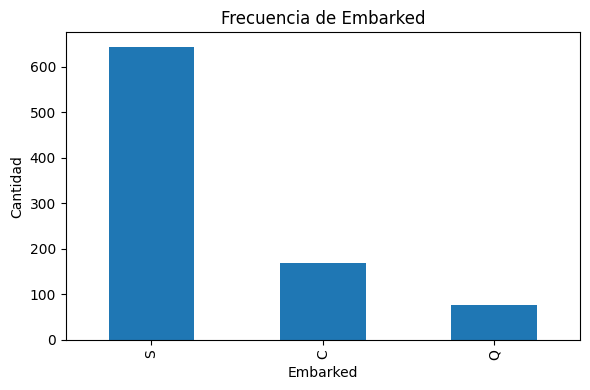

In [38]:
cat_cols = ["Sex", "Pclass", "Embarked"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].astype(str).value_counts().plot(kind="bar")
    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()

Supervivencia por sexo (%):


Survived,0,1
Sex,,
female,25.80,74.20
male,81.11,18.89


Supervivencia por clase (%):


Survived,0,1
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


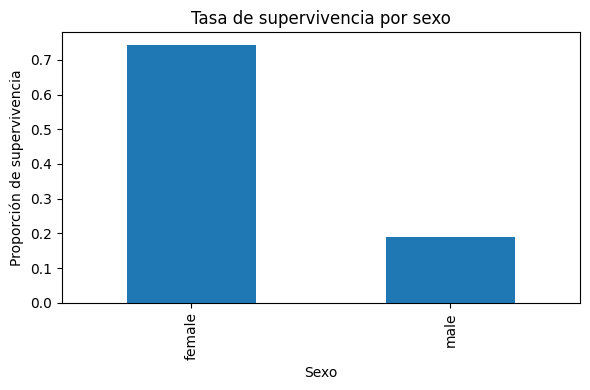

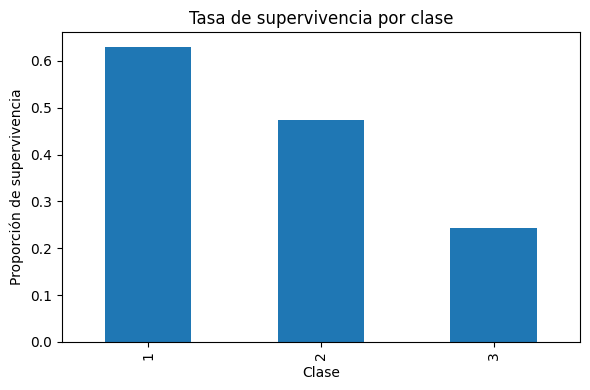

In [39]:
survival_by_sex = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
survival_by_pclass = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100

print("Supervivencia por sexo (%):")
display(survival_by_sex.round(2))

print("Supervivencia por clase (%):")
display(survival_by_pclass.round(2))

plt.figure(figsize=(6,4))
pd.crosstab(df["Sex"], df["Survived"], normalize="index")[1].plot(kind="bar")
plt.title("Tasa de supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Proporción de supervivencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
pd.crosstab(df["Pclass"], df["Survived"], normalize="index")[1].plot(kind="bar")
plt.title("Tasa de supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Proporción de supervivencia")
plt.tight_layout()
plt.show()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000,-0.338,-0.077,-0.035,0.082,0.257
Pclass,-0.338,1.000,-0.369,0.083,0.018,-0.549
Age,-0.077,-0.369,1.000,-0.308,-0.189,0.096
SibSp,-0.035,0.083,-0.308,1.000,0.415,0.160
Parch,0.082,0.018,-0.189,0.415,1.000,0.216
Fare,0.257,-0.549,0.096,0.160,0.216,1.000


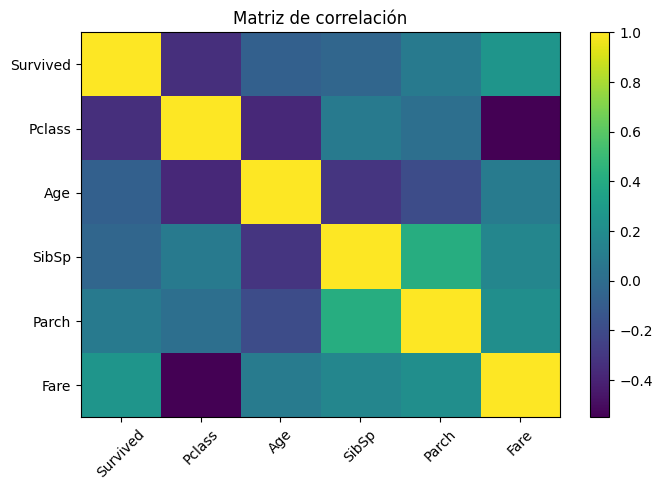

In [40]:
corr = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr()

display(corr.round(3))

plt.figure(figsize=(7,5))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [41]:
def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        series = dataframe[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (series < lower) | (series > upper)
        rows.append({
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outliers_count": int(mask.sum()),
            "outliers_pct": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows)

outlier_table = iqr_outlier_summary(df, ["Age", "Fare", "SibSp", "Parch"])
display(outlier_table)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outliers_count,outliers_pct
0,Age,20.1250,38.0,17.8750,-6.6875,64.8125,11,1.54
1,Fare,7.9104,31.0,23.0896,-26.7240,65.6344,116,13.02
2,SibSp,0.0000,1.0,1.0000,-1.5000,2.5000,46,5.16
3,Parch,0.0000,0.0,0.0000,0.0000,0.0000,213,23.91


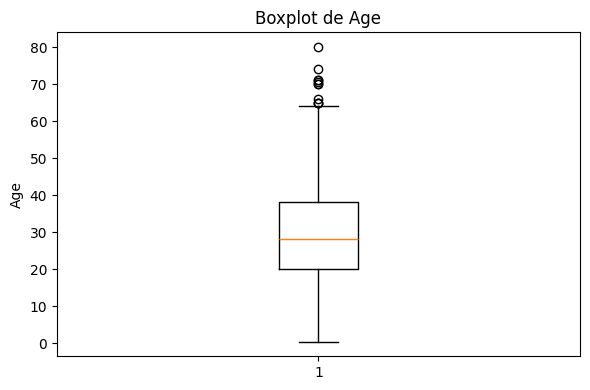

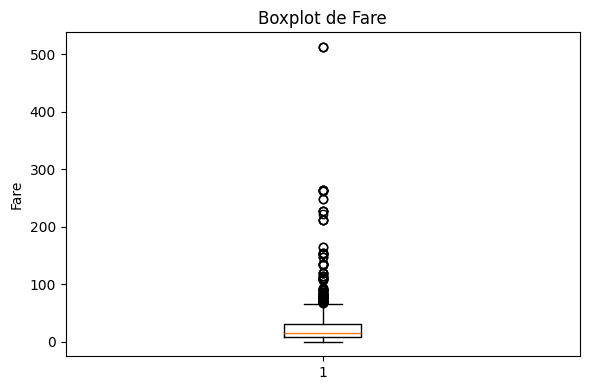

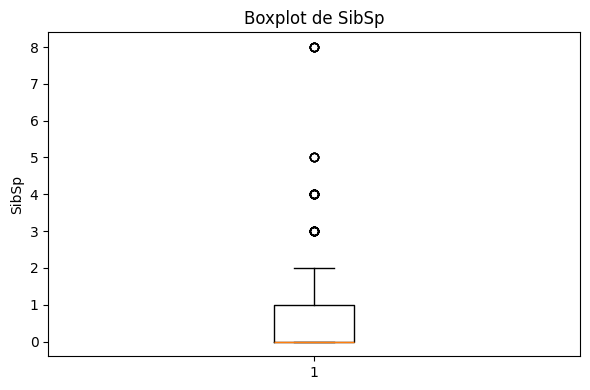

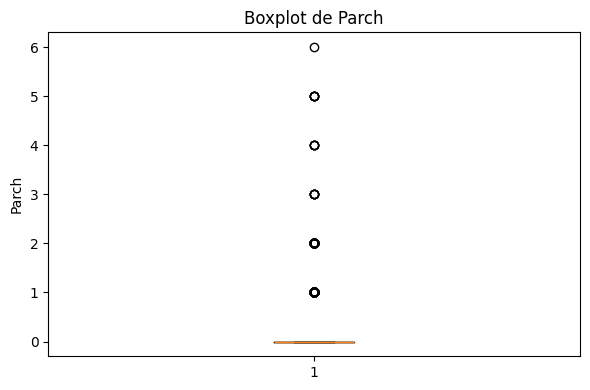

In [42]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 2. Limpieza de datos

A partir del análisis exploratorio se identificaron tres problemas principales de calidad de datos:

1. **Valores faltantes** en variables como `Age`, `Cabin` y `Embarked`.  
2. **Variables con baja utilidad directa** para un modelo base, como `Ticket`, `Name` y `Cabin`.  
3. **Presencia de valores atípicos**, especialmente en `Fare`, aunque estos no necesariamente corresponden a errores, sino a pasajeros con tarifas muy superiores al promedio.

### Decisiones adoptadas

- `Cabin` se elimina debido a su elevado nivel de valores faltantes.  
- `Name` y `Ticket` se eliminan en esta primera versión del pipeline, porque requieren ingeniería de variables más avanzada para extraer valor.  
- `Age` se imputará con la **mediana**, ya que es una variable numérica con posibles outliers.  
- `Embarked` se imputará con la **moda**, porque es una variable categórica.  
- Los outliers de `Fare` **no se eliminan** automáticamente, ya que pueden representar observaciones reales y relevantes desde el punto de vista socioeconómico.

In [43]:
df_clean = df.copy()

columns_to_drop = ["Cabin", "Name", "Ticket", "PassengerId"]
df_clean = df_clean.drop(columns=columns_to_drop)

print("Dimensiones después de eliminar columnas:", df_clean.shape)
display(df_clean.head())

Dimensiones después de eliminar columnas: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [44]:
# rehacer limpieza desde cero
df_clean = df.copy()

# eliminar columnas
df_clean = df_clean.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])

# imputar faltantes
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# verificar
print(df_clean.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [45]:
print("Valores faltantes después de eliminar columnas:")
display(df_clean.isnull().sum().sort_values(ascending=False))

Valores faltantes después de eliminar columnas:


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## 3. Comparación de frameworks de analítica de datos

### 3.1 CRISP-DM
CRISP-DM es un framework ampliamente utilizado en minería de datos y ciencia de datos. Se organiza en seis etapas: comprensión del negocio, comprensión de los datos, preparación de los datos, modelado, evaluación y despliegue. Su principal fortaleza es que permite ordenar un proyecto de forma iterativa y comprensible tanto para perfiles técnicos como no técnicos.

**Alcances:**  
- Entrega una visión integral del proyecto.  
- Facilita documentar el proceso de análisis.  
- Se adapta bien a problemas de clasificación como Titanic.  

**Limitaciones:**  
- No prescribe herramientas concretas.  
- Puede resultar general en contextos muy complejos.  

### 3.2 KDD
KDD se orienta al descubrimiento de conocimiento en bases de datos. Sus fases incluyen selección, preprocesamiento, transformación, minería de datos e interpretación.

**Alcances:**  
- Es útil para entender el flujo clásico de extracción de conocimiento.  
- Tiene fuerte énfasis en el análisis y descubrimiento de patrones.  

**Limitaciones:**  
- Tiene menor foco en el entendimiento del negocio.  
- No enfatiza de forma explícita la implementación del modelo.  

### 3.3 TDSP
El Team Data Science Process fue impulsado por Microsoft y destaca por incorporar prácticas colaborativas, control de versiones y enfoque de ingeniería.

**Alcances:**  
- Muy útil para trabajo con repositorio y trazabilidad.  
- Favorece la reproducibilidad.  
- Se alinea bien con el uso de GitHub.  

**Limitaciones:**  
- Puede ser más exigente para proyectos pequeños.  
- Requiere mayor disciplina técnica y organizacional.  

### 3.4 Framework seleccionado
Para este trabajo se selecciona **CRISP-DM** como marco principal, debido a que organiza claramente el flujo del proyecto y se adapta de forma natural al problema Titanic. No obstante, se incorporan elementos de TDSP en la parte de versionado y reproducibilidad mediante GitHub. Esta combinación resulta adecuada para un trabajo académico, ya que permite cubrir tanto el razonamiento metodológico como la gestión ordenada del código.

## 4. Métodos de división de datos

La separación entre entrenamiento, validación y prueba es una etapa fundamental, ya que evita evaluar el modelo sobre datos ya vistos y mejora la estimación de su capacidad de generalización.

### Método 1: Hold-out simple
Consiste en dividir el dataset en dos grupos: entrenamiento y prueba.

**Ventajas:**  
- Es simple y rápido.  
- Fácil de implementar en problemas introductorios.  

**Desventajas:**  
- El resultado depende mucho de una sola partición.  
- No deja un conjunto separado para validación.  

### Método 2: Train / Validation / Test
Se divide el dataset en tres subconjuntos: entrenamiento, validación y prueba.

**Ventajas:**  
- Permite ajustar decisiones usando validación sin tocar el test.  
- Es un buen equilibrio entre simplicidad y control metodológico.  

**Desventajas:**  
- Reduce la cantidad de datos disponibles para entrenar.  

### Método 3: Cross-validation
Se divide el conjunto en varios pliegues y se repite el entrenamiento varias veces.

**Ventajas:**  
- Entrega una evaluación más robusta.  
- Reduce la dependencia de una sola partición.  

**Desventajas:**  
- Mayor costo computacional.  
- Puede ser menos intuitivo para una primera implementación.  

### Método elegido
En este trabajo se utilizará el esquema **Train / Validation / Test**, debido a que permite mostrar con claridad la lógica de desarrollo, ajuste y evaluación final del modelo. Además, como la variable objetivo está desbalanceada moderadamente, se aplicará división estratificada para conservar la proporción de supervivencia en cada subconjunto.

In [46]:
X = df_clean.drop(columns="Survived")
y = df_clean["Survived"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (891, 7)
Shape de y: (891,)


In [47]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Tamaño entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño validación:", X_val.shape, y_val.shape)
print("Tamaño test:", X_test.shape, y_test.shape)

Tamaño entrenamiento: (534, 7) (534,)
Tamaño validación: (178, 7) (178,)
Tamaño test: (179, 7) (179,)


In [48]:
def target_distribution(name, target):
    dist = target.value_counts(normalize=True).sort_index() * 100
    print(f"\nDistribución de Survived en {name}:")
    print(dist.round(2))

target_distribution("Train", y_train)
target_distribution("Validation", y_val)
target_distribution("Test", y_test)


Distribución de Survived en Train:
Survived
0    61.61
1    38.39
Name: proportion, dtype: float64

Distribución de Survived en Validation:
Survived
0    61.8
1    38.2
Name: proportion, dtype: float64

Distribución de Survived en Test:
Survived
0    61.45
1    38.55
Name: proportion, dtype: float64


In [49]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [50]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [51]:
y_val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
print("Accuracy en validación:", round(val_accuracy, 4))

print("\nClassification report - Validación")
print(classification_report(y_val, y_val_pred))

Accuracy en validación: 0.7921

Classification report - Validación
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.69      0.72        68

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.78       178
weighted avg       0.79      0.79      0.79       178



In [52]:
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy en test:", round(test_accuracy, 4))

print("\nClassification report - Test")
print(classification_report(y_test, y_test_pred))

print("\nMatriz de confusión - Test")
print(confusion_matrix(y_test, y_test_pred))

Accuracy en test: 0.7989

Classification report - Test
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Matriz de confusión - Test
[[94 16]
 [20 49]]


In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    model, X, y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy por fold:", np.round(cv_scores, 4))
print("Accuracy promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

Accuracy por fold: [0.7709 0.8034 0.7921 0.7809 0.8202]
Accuracy promedio CV: 0.7935
Desviación estándar CV: 0.0172


## 5. Resultados y análisis

El análisis exploratorio permitió identificar que el dataset presenta una combinación de variables numéricas y categóricas, junto con valores faltantes relevantes en `Age`, `Cabin` y `Embarked`. La eliminación de `Cabin` se justificó por su alto nivel de ausencia, mientras que `Age` y `Embarked` fueron tratadas mediante imputación, lo que permitió conservar observaciones sin perder consistencia metodológica.

En el plano descriptivo, se observó que la supervivencia no se distribuye de manera uniforme entre los pasajeros. Las mujeres presentan una probabilidad de supervivencia considerablemente mayor que los hombres, y los pasajeros de clases más altas muestran mejores resultados que aquellos ubicados en clases inferiores. Estos patrones sugieren que variables como `Sex` y `Pclass` poseen una relación importante con la variable objetivo.

Respecto del split de datos, se optó por la estrategia **Train / Validation / Test** con estratificación, ya que entrega un esquema equilibrado entre desarrollo, ajuste y evaluación final. Este enfoque permite reservar un conjunto verdaderamente no visto para la etapa final de prueba, evitando decisiones metodológicas sobre el mismo.

Finalmente, se entrenó un modelo base de regresión logística como referencia inicial. El objetivo de esta etapa no fue maximizar el rendimiento predictivo, sino demostrar un pipeline reproducible y metodológicamente consistente, alineado con los requerimientos de la actividad.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_clean.drop("Survived", axis=1)
y = df_clean["Survived"]

num_cols = ["Age", "Fare", "SibSp", "Parch"]
cat_cols = ["Sex", "Embarked", "Pclass"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte:\n", classification_report(y_test, y_pred))
print("\nMatriz:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7988826815642458

Reporte:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Matriz:
 [[90 15]
 [21 53]]


### Interpretación del modelo logístico

El modelo de regresión logística obtuvo un accuracy de aproximadamente 0.80, lo que indica que clasifica correctamente cerca del 80% de los casos del conjunto de prueba.

En la clase 0 (no sobrevivió), el modelo presenta mejor desempeño, con una precisión de 0.81 y un recall de 0.86. En la clase 1 (sobrevivió), el desempeño es algo menor, con precisión de 0.78 y recall de 0.72.

Esto sugiere que el modelo identifica mejor a los pasajeros que no sobrevivieron que a los que sí sobrevivieron. Aun así, el resultado general es adecuado para un modelo base y demuestra que variables como sexo, clase y edad aportan información relevante para predecir la supervivencia.

In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("Accuracy por fold:", scores)
print("Accuracy promedio CV:", scores.mean())
print("Desviación estándar CV:", scores.std())

Accuracy por fold: [0.78212291 0.80898876 0.78651685 0.76966292 0.83707865]
Accuracy promedio CV: 0.7968740192078339
Desviación estándar CV: 0.023784404991218734


### Interpretación de la validación cruzada

La validación cruzada de 5 folds permite evaluar la estabilidad del modelo en distintos subconjuntos del dataset. Si el accuracy promedio es cercano al obtenido en el conjunto de prueba y la desviación estándar es baja, se puede concluir que el modelo presenta un comportamiento consistente y generaliza de manera adecuada.

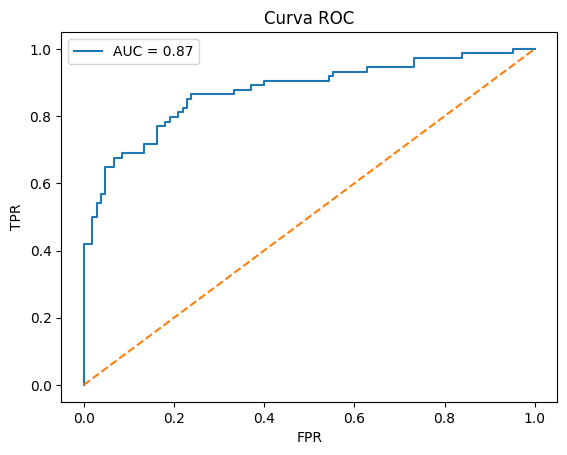

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print("\nReporte RF:\n", classification_report(y_test, y_pred_rf))

Accuracy RF: 0.8156424581005587

Reporte RF:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [58]:
print("Modelo Logístico:", accuracy_score(y_test, y_pred))
print("Modelo Random Forest:", accuracy_score(y_test, y_pred_rf))

Modelo Logístico: 0.7988826815642458
Modelo Random Forest: 0.8156424581005587


Se compararon dos modelos de clasificación: regresión logística y Random Forest. 

La regresión logística obtuvo una precisión cercana al 80%, destacando por su simplicidad e interpretabilidad. Este modelo permite comprender la influencia de las variables sobre la probabilidad de supervivencia, lo cual es útil en contextos explicativos.

Por otro lado, el modelo Random Forest alcanzó una precisión superior (≈82%), evidenciando una mejor capacidad para capturar relaciones no lineales y patrones complejos en los datos. Además, mostró un mejor equilibrio entre precisión y recall, especialmente en la clase positiva (supervivencia).

En consecuencia, Random Forest presenta un mejor desempeño predictivo general, mientras que la regresión logística sigue siendo relevante por su interpretabilidad. La elección final depende del objetivo del análisis: predicción vs. explicación.

Adicionalmente, el análisis mediante la curva ROC (AUC ≈ 0.87) confirma la alta capacidad discriminativa del modelo Random Forest.

## Conclusión

El desarrollo de este trabajo permitió aplicar de manera ordenada los principales componentes de un pipeline de analítica de datos y aprendizaje automático sobre el dataset Titanic. A nivel metodológico, la comparación entre CRISP-DM, KDD y TDSP permitió justificar la elección de CRISP-DM como marco central de trabajo, complementado con prácticas de reproducibilidad propias de TDSP.

Desde la perspectiva de calidad de datos, el análisis exploratorio mostró que la limpieza no debe entenderse como una etapa mecánica, sino como un proceso de toma de decisiones fundamentadas. La imputación de valores faltantes, la eliminación de variables con exceso de ausencia y la revisión de outliers permitieron preparar una base de datos consistente para el modelado inicial.

En relación con la división del dataset, se concluyó que el esquema Train / Validation / Test es una alternativa adecuada para este caso, porque facilita el ajuste del modelo sin comprometer la objetividad de la evaluación final. Además, el uso de estratificación contribuyó a conservar la proporción de la variable objetivo en cada subconjunto.

En síntesis, este trabajo evidencia que la calidad de un proyecto de ciencia de datos no depende únicamente del modelo utilizado, sino de la correcta integración entre comprensión del problema, preparación de los datos, modelado y evaluación. Este enfoque estructurado permite obtener resultados confiables y reproducibles, incluso en contextos introductorios como el dataset Titanic.

## Bibliografía

- Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*.  
- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine, 17*(3), 37–54.  
- Microsoft. (2024). *Team Data Science Process*.  
- Kaggle. (2024). *Titanic - Machine Learning from Disaster*.  